<a href="https://colab.research.google.com/github/juliafarah/MVP_Data_Analysis/blob/main/MVP_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MVP Data Analysis**

**Aluna:** Julia Farah *(Matr.: 4052025001969)*

**Data:** 12/04/2026

**Assunto**: Identificação de Gargalos de Lead Time

### **Introdução**

* **Definição e Descrição do Problema**

Em uma economia globalizada, a eficiência da cadeia de suprimentos é um fator crítico para a competitividade e sobrevivência das multinacionais. O gerenciamento de uma malha logística em escala global, que opera simultaneamente com quatro modais de transporte (Marítimo, Aéreo, Rodoviário e Ferroviário), apresenta uma altíssima complexidade. Atrasos ou interrupções nesse fluxo, frequentemente causados por fatores externos incontroláveis, podem comprometer a continuidade das operações de ponta a ponta, gerando gargalos produtivos, quebra de nível de serviço (SLA) e perdas financeiras significativas.


**Fonte:** [Kaggle](https://www.kaggle.com/datasets/nudratabbas/global-supply-chain-risk-and-logistics-2024-2026)


* **Objetivo do MVP**

Este projeto utiliza um dataset de movimentações de carga globais para identificar os principais fatores de risco e interrupção na cadeia de suprimentos. O objetivo é conduzir uma Análise Exploratória de Dados (EDA) que **avalie a vulnerabilidade** e o **tempo de entrega (Lead Time) de cada modal** frente a variáveis críticas, como instabilidade geopolítica e severidade climática. *O foco é extrair insights claros para suportar a tomada de decisão estratégica da gerência e, propor planos de ação com o intuito de mitigar de atrasos e a construir uma operação logística mais resiliente.*


* **Tipo de Aprendizado:** Supervisionado (Classificação)

* **Definição dos Atributos**

**`Shipment_ID`** : Identificador único da carga.

**`Date`** : Data de despacho da carga (2024 a 2026).

**`Origin_Port`** : Portos de origem (Hubs globais)

**`Destination_Port`** : Portos de destino (Hubs globais).

**`Transport_Mode`** : Modal (Sea, Air, Rail, Road).

**`Distance_km`** : Distância total percorrida.

**`Weight_MT`** : Peso da carga em Toneladas Métricas.

 **`Fuel_Price_Index`** : Índice de custo de combustível no despacho.

 **`Geopolitical_Risk_Score`** : Índice de risco regional (0 a 10).

 **`Weather_Condition`** : Condição climática (Clear, Storm, Hurricane, etc).

 **`Carrier_Reliability_Score`** : Score de confiabilidade do transportador (0.5 a 1.0).

**`Lead_Time_Days`** : Tempo real de entrega (Variável Alvo para Regressão).

**`Disruption_Occurred`** : Flag de interrupção ou atraso (0: Não / 1: Sim). **(target)**

# **1. Pre Processamento dos Dados**

### **1.1. Importando as bibliotecas e carregando o dataset**

In [1]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carregando o arquivo (certifique-se de que o nome está idêntico ao do arquivo subido)
df = pd.read_csv('https://raw.githubusercontent.com/juliafarah/MVP_Data_Analysis/refs/heads/main/global_supply_chain_risk_2026.csv')

# Visualizando as 5 primeiras linhas para confirmar que funcionou
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


### **1.2. Detalhes dos atributos**

In [3]:
print("Quantidade de linhas e colunas:", df.shape)

Quantidade de linhas e colunas: (5000, 14)


In [4]:
# Mostra o tipo de cada coluna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   object 
 1   Date                       5000 non-null   object 
 2   Origin_Port                5000 non-null   object 
 3   Destination_Port           5000 non-null   object 
 4   Transport_Mode             5000 non-null   object 
 5   Product_Category           5000 non-null   object 
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   object 
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64

### **1.3. Verificação de valores nulos**

In [5]:
df.isnull().sum()

,0
Shipment_ID,0
Date,0
Origin_Port,0
Destination_Port,0
Transport_Mode,0
Product_Category,0
Distance_km,0
Weight_MT,0
Fuel_Price_Index,0
Geopolitical_Risk_Score,0


### **1.4. Checar duplicidade**

In [6]:
df.duplicated().sum()

np.int64(0)

### **1.5. Resumo estatístico**

In [7]:
df.describe()


,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600
std,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205
min,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000


### **1.6. Converter o tipo da coluna `Date` de object para datetime**




In [8]:

df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Shipment_ID                5000 non-null   object        
 1   Date                       5000 non-null   datetime64[ns]
 2   Origin_Port                5000 non-null   object        
 3   Destination_Port           5000 non-null   object        
 4   Transport_Mode             5000 non-null   object        
 5   Product_Category           5000 non-null   object        
 6   Distance_km                5000 non-null   float64       
 7   Weight_MT                  5000 non-null   float64       
 8   Fuel_Price_Index           5000 non-null   float64       
 9   Geopolitical_Risk_Score    5000 non-null   float64       
 10  Weather_Condition          5000 non-null   object        
 11  Carrier_Reliability_Score  5000 non-null   float64       
 12  Lead_T

### **1.7. Definindo colunas por tipo (numéricas e categóricas)**


In [9]:
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
colunas_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f"Atributos Numéricos: {colunas_numericas}\n")
print(f"Atributos Categóricos: {colunas_categoricas}")

Atributos Numéricos: ['Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Carrier_Reliability_Score', 'Lead_Time_Days', 'Disruption_Occurred']

Atributos Categóricos: ['Shipment_ID', 'Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Weather_Condition']


### **1.8. Verificação manual de inconsistências comuns em Supply Chain**


In [10]:
inc1 = df[ (df['Lead_Time_Days'] <= 0) ].shape[0]
inc2 = df[(df['Distance_km'] <= 0)].shape[0]
inc3 = df[(df['Weight_MT'] <= 0)].shape[0]
inc4 = df[(df['Fuel_Price_Index'] <= 0)].shape[0]
inc5 = df[(df['Geopolitical_Risk_Score'] < 0) | (df['Geopolitical_Risk_Score'] > 10)].shape[0]
inc6 = df[(df['Carrier_Reliability_Score'] < 0.5) | (df['Carrier_Reliability_Score'] > 1.0)].shape[0]

inconsistencias_list = [
    ('Lead_Time_Days <= 0', inc1),
    ('Distance_km <= 0', inc2),
    ('Weight_MT <= 0', inc3),
    ('Fuel_Price_Index <= 0', inc4),
    ('Geopolitical_Risk_Score not in [0, 10]', inc5),
    ('Carrier_Reliability_Score not in [0.5, 1.0]', inc6)
]

detected_issues = []
for desc, count in inconsistencias_list:
    if count > 0:
        detected_issues.append(f"{desc}: {count}")

if detected_issues:
    print("Inconsistências encontradas:")
    for issue in detected_issues:
        print(f"- {issue}")
else:
    print("Nenhuma inconsistência encontrada.")

Nenhuma inconsistência encontrada.


### **1.9. Matriz de Correlação**


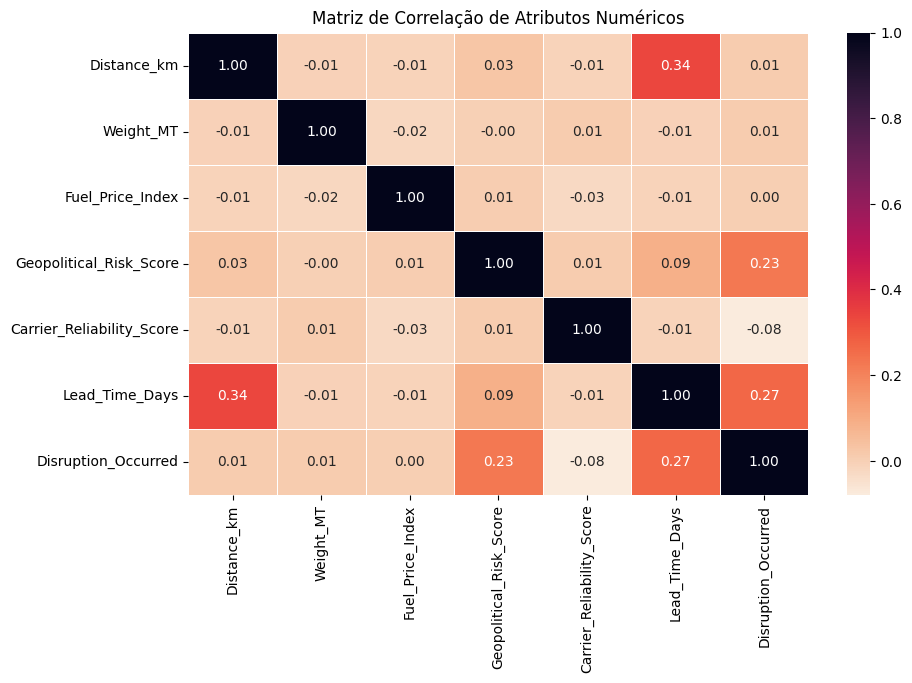

In [11]:
plt.figure(figsize=(10, 6))

# Removendo ID e datas para a correlação numérica
corr = df[colunas_numericas].corr()
sns.heatmap(corr, annot=True, cmap='rocket_r', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação de Atributos Numéricos')
plt.show()

**Insights relevantes:**

Destaca-se a correlação positiva de **0.34** entre **`Distance_km`** e **`Lead_Time_Days`**, confirmando que a distância é um fator que mais impacta diretamente o tempo de entrega.

Outro ponto relevante é a correlação de **0.23** entre **`Geopolitical_Risk_Score`** e **`Disruption_Occurred`**, sugere que existe uma relação positiva, embora moderada, entre o risco geopolítico e a ocorrência de interrupções. Isso significa que, à medida que o risco geopolítico aumenta, a probabilidade de uma interrupção ocorrer na cadeia de suprimentos também tende a aumentar.

A ausência de correlações extremamente altas (acima de 0.8) entre variáveis independentes afasta o risco de multicolinearidade, garantindo estabilidade para futuros modelos de regressão ou classificação.

### **1.10. Verificando outliers (anomalias)**

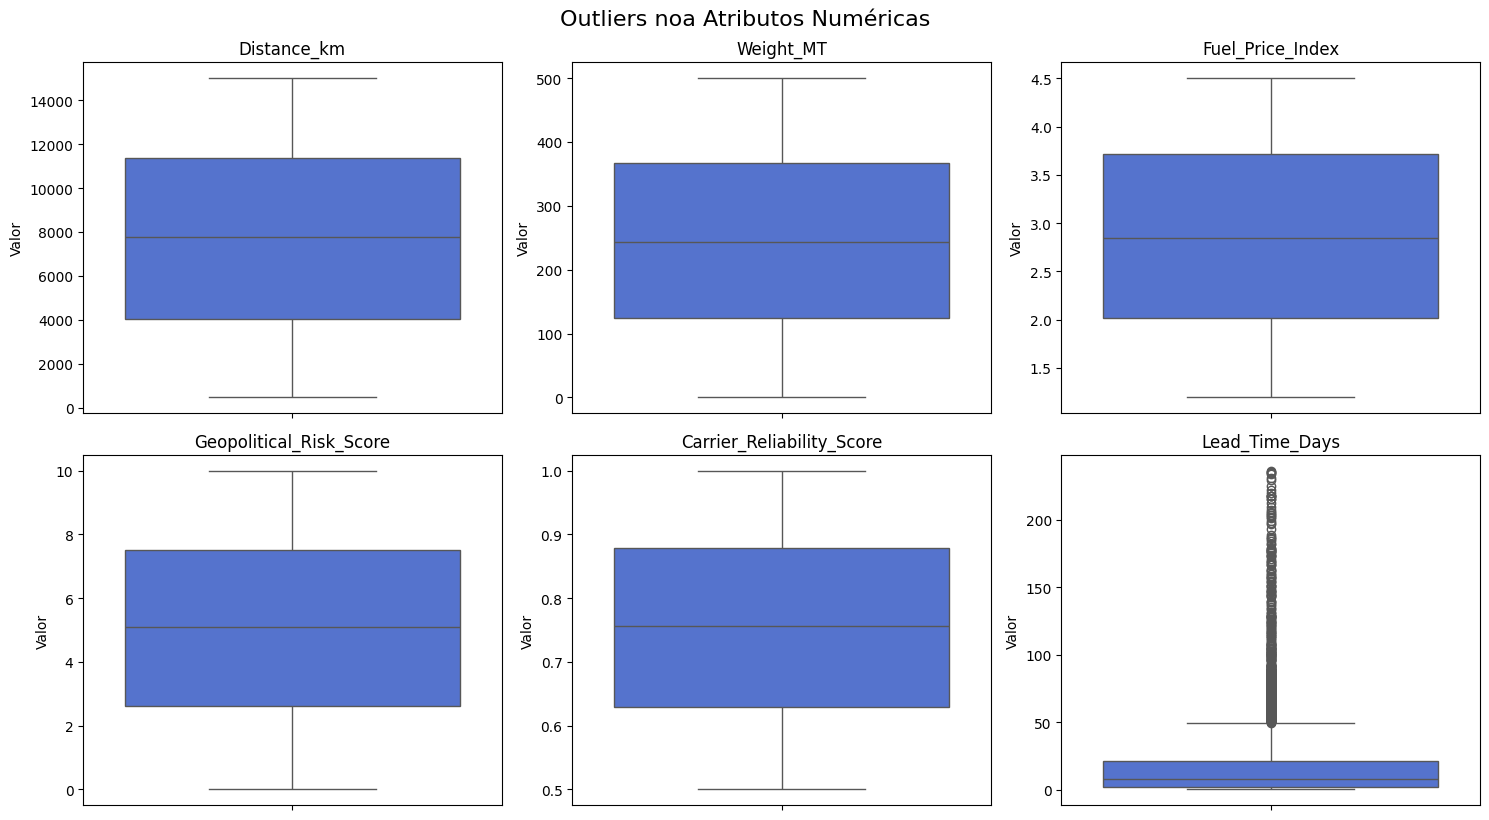

In [12]:
# Visualização de outliers para todas as colunas numéricas (Layout 2x3)
plt.figure(figsize=(15, 8))

# Selecionando apenas as colunas de escala contínua
cols_boxplot = [c for c in colunas_numericas if c != 'Disruption_Occurred']

for i, col in enumerate(cols_boxplot):
    plt.subplot(2, 3, i+1)  # Ajustando para 2 linhas e 3 colunas
    sns.boxplot(y=df[col], color='royalblue')
    plt.title(f'{col}')
    plt.ylabel('Valor')

plt.tight_layout()
plt.suptitle('Outliers noa Atributos Numéricas', fontsize=16, y=1.02)
plt.show()

**Insights interessantes:**

O atributo `Lead_Time_Days`, destaca-se com uma quantidade significativa de valores acima do limite superior (*outliers*). **Estes valores não representam erros de coleta ou ruídos, mas sim casos reais de interrupções críticas.** Em logística global, eventos como severidade climática extrema e crises geopolíticas podem elevar substancialmente o tempo de entrega.

Desta forma, optou-se por **manter os outliers**. Visto que, removê-los mascararia a realidade operacional e impediria que futuras modelagens identificassem os cenários de maior risco. Porém, é uma estratégia que poderá ser revista posteriormente, durante a preparação do treinamento dos modelos de ML.

### **1.11. Tipo de distribuição de cada atributo numéricos**

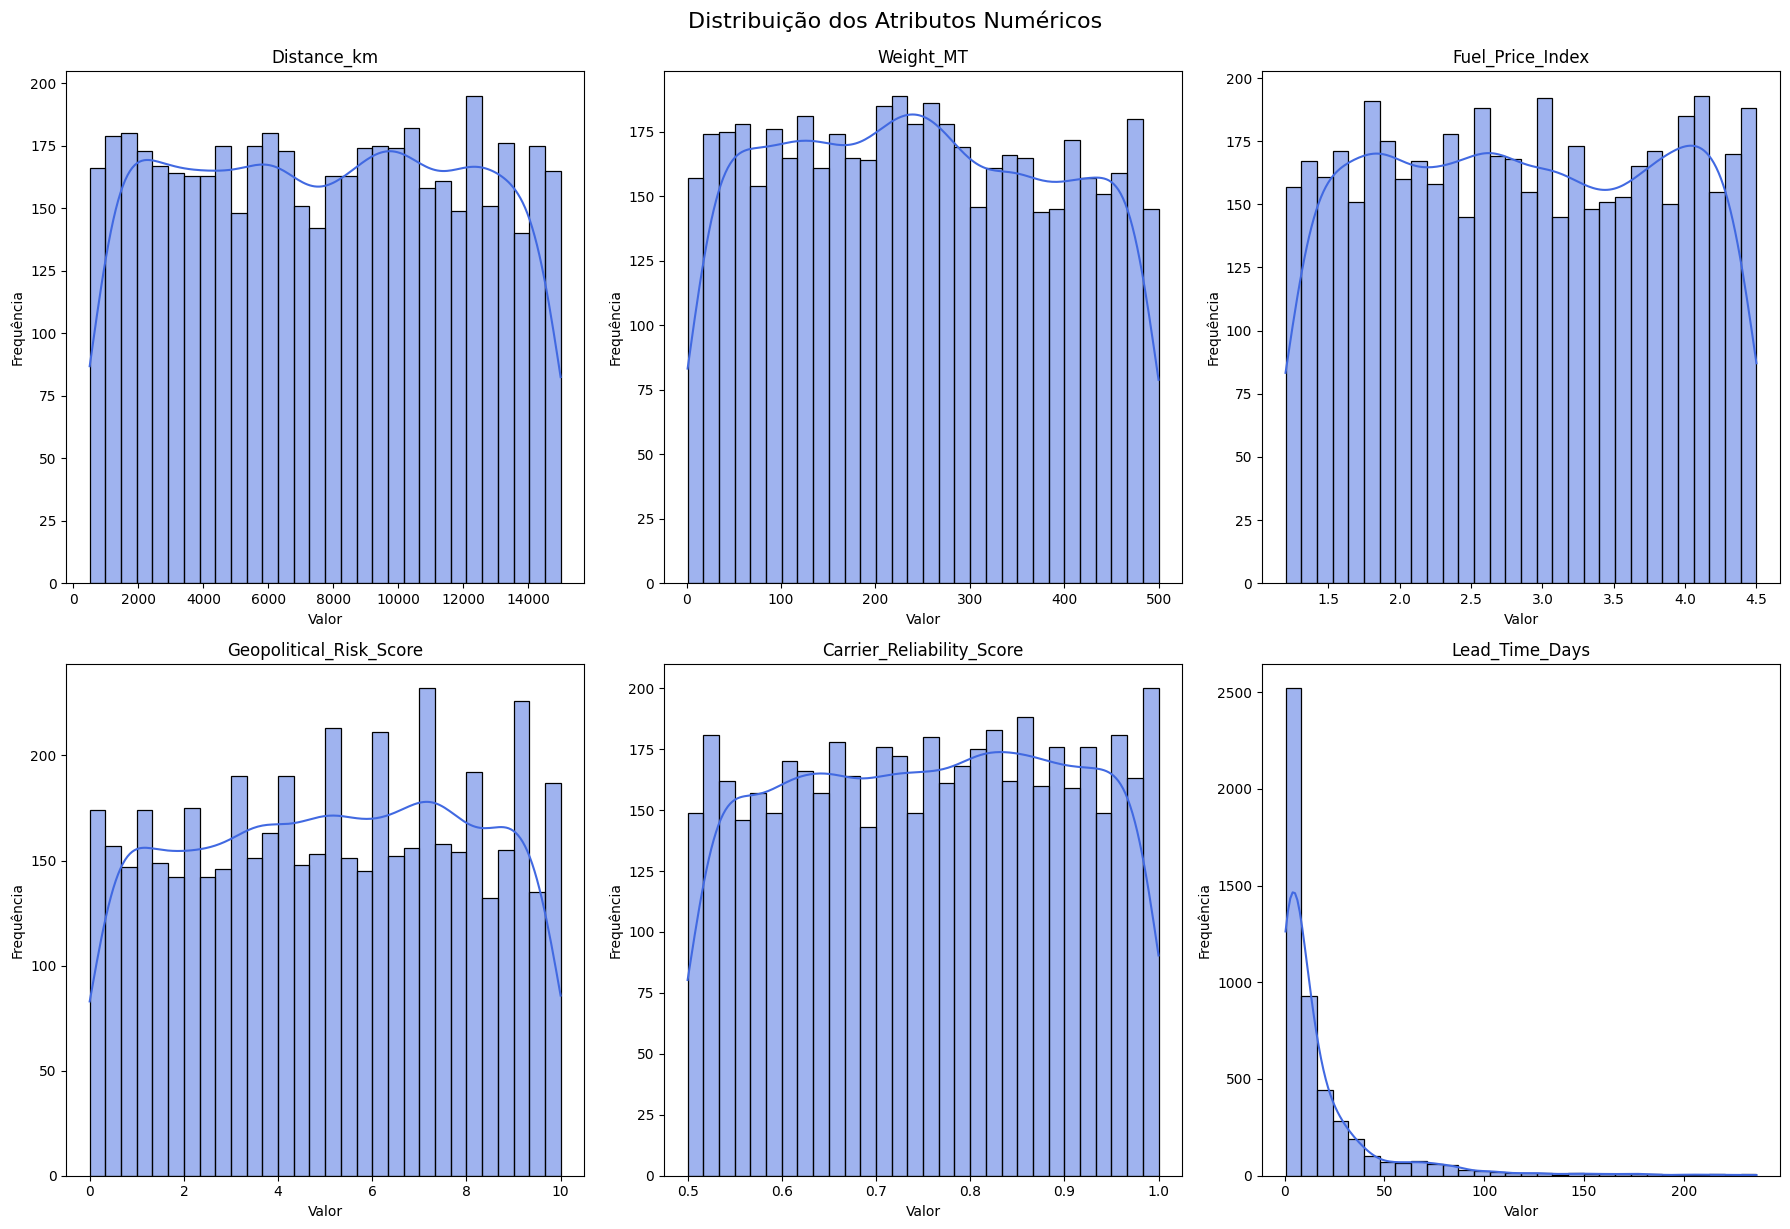

In [13]:
plt.figure(figsize=(18, 12))


cols_to_plot = ['Distance_km', 'Weight_MT', 'Fuel_Price_Index',
                'Geopolitical_Risk_Score', 'Carrier_Reliability_Score', 'Lead_Time_Days']

for i, col in enumerate(cols_to_plot):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True, color='royalblue', bins=30)
    plt.title(col)
    plt.xlabel('Valor')
    plt.ylabel('Frequência')

plt.tight_layout()
plt.suptitle('Distribuição dos Atributos Numéricos', fontsize=16, y=1.02)
plt.show()

**Insights relevantes:**

Nota-se que a maioria dos atributos numéricos (como **`Distance_km`** e **`Weight_MT`**) apresenta uma distribuição aproximadamente uniforme, indicando uma amostragem equilibrada. No entanto, o atributo alvo **`Lead_Time_Days`** exibe uma forte assimetria à direita.

> Próximos passos para preparação de dados:

* Devido às discrepâncias de escala entre os atributos (milhares em **`Distance_km`** vs. decimais em **`Carrier_Reliability`**), será necessária a aplicação de **Normalização** para que todas as variáveis contribuam igualmente para o aprendizado do modelo. *(não realizada neste projeto pois os atributos não serão usados na EDA)*

* A cauda longa no **`Lead_Time_Days`** reforça a decisão de não remover os outliers, mas sugere que uma **discretização** em faixas de atraso seria benéfica para reduzir o viés causado pelos valores extremos em futuros algoritmos.

### **1.12. Discretização**

*Para análise EDA e preparação para treinar modelos de ML*

In [14]:
from sklearn.preprocessing import MinMaxScaler

# Criando uma cópia para preservar o original
df_processed = df.copy()

# CALCULO DAS MÉDIAS POR MODAL (Base para a Discretização)
modal_means = df.groupby('Transport_Mode')['Lead_Time_Days'].mean()

# FUNÇÃO DE DISCRETIZAÇÃO DINÂMICA
def categorizar_por_modal(row, medias):
    modal = row['Transport_Mode']
    tempo = row['Lead_Time_Days']
    media_referencia = medias[modal]

    # On Time (até a média), Delayed (até 25% acima da média), Critical (mais que 50% acima)
    if tempo <= media_referencia:
        return 'On-time'
    elif tempo <= (media_referencia * 1.75):
        return 'Delayed'
    else:
        return 'Critical'

# DISCRETIZAÇÃO
df_processed['Lead_Time_Category'] = df.apply(categorizar_por_modal, axis=1, args=(modal_means,))

# NORMALIZAÇÃO (Min-Max Scaling)
scaler = MinMaxScaler()
cols_para_normalizar = [
    'Distance_km', 'Weight_MT', 'Fuel_Price_Index',
    'Geopolitical_Risk_Score', 'Carrier_Reliability_Score'
]
df_processed[cols_para_normalizar] = scaler.fit_transform(df[cols_para_normalizar])

# ORDINAL ENCODING (Clima)
weather_map = {'Clear': 1, 'Fog': 2, 'Storm': 3, 'Hurricane': 4}
df_processed['Weather_Severity_Rank'] = df['Weather_Condition'].map(weather_map)

# Criando a coluna numérica (Ordinal Encoding para o Modelo de ML)
status_map = {'On-time': 0, 'Delayed': 1, 'Critical': 2}
df_processed['Lead_Time_Label'] = df_processed['Lead_Time_Category'].map(status_map)


display(df_processed[['Transport_Mode', 'Lead_Time_Days', 'Lead_Time_Category']].head())
display(modal_means)

,Transport_Mode,Lead_Time_Days,Lead_Time_Category
0,Rail,41.39,Critical
1,Rail,40.92,Critical
2,Rail,11.54,On-time
3,Rail,53.13,Critical
4,Air,0.50,On-time


,Lead_Time_Days
Transport_Mode,
Air,1.644273
Rail,19.954253
Road,16.452306
Sea,39.802966


###**1.13. Criação da coluna `Weather_Severity_Rank` para ordernar cada condição climática por grau de severidade.**

In [15]:
# quais tipos de condicoes climaticas tem na coluna Weather_Condition
print("\nLista de valores únicos:")
print(df['Weather_Condition'].unique())


Lista de valores únicos:
['Hurricane' 'Storm' 'Rain' 'Fog' 'Clear']


In [16]:
# mantem a coluna original 'Weather_Condition' e cria a nova 'Weather_Severity_Rank'

mapping_clima = {
    'Clear': 1,
    'Rain': 2,
    'Fog': 3,
    'Storm': 3,
    'Hurricane': 4
}

# nova coluna de ranking
df['Weather_Severity_Rank'] = df['Weather_Condition'].map(mapping_clima)

# double check se a criaçao foi bem sucedida
print("Amostra dos dados com a nova coluna do ranking:")
display(df[['Weather_Condition', 'Weather_Severity_Rank']].head(10))

# media de Lead Time pelo ranking
print("\nLead Time médio por nível do ranking:")
display(df.groupby(['Weather_Condition', 'Weather_Severity_Rank'])['Lead_Time_Days'].mean())

print("\nO dataframe completo:")
df.head(10)

Amostra dos dados com a nova coluna do ranking:


,Weather_Condition,Weather_Severity_Rank
0,Hurricane,4
1,Storm,3
2,Rain,2
3,Hurricane,4
4,Fog,3
5,Rain,2
6,Storm,3
7,Fog,3
8,Clear,1
9,Storm,3



Lead Time médio por nível do ranking:


,,Lead_Time_Days
Weather_Condition,Weather_Severity_Rank,
Clear,1,6.698704
Fog,3,9.892847
Hurricane,4,53.501848
Rain,2,7.736049
Storm,3,19.299182



O dataframe completo:


,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred,Weather_Severity_Rank
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1,4
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1,3
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0,2
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1,4
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1,3
5,SC-10005,2024-08-16,Rotterdam,Marseille,Rail,Automotive,2761.92,44.98,4.06,2.2,Rain,0.869,2.16,1,2
6,SC-10006,2024-05-22,Shanghai,Antwerp,Rail,Pharmaceuticals,1342.21,388.62,1.31,2.6,Storm,0.981,2.99,0,3
7,SC-10007,2024-04-14,Busan,Antwerp,Air,Textiles,13059.55,423.93,3.32,5.7,Fog,0.558,1.25,1,3
8,SC-10008,2025-11-23,Dubai,Marseille,Air,Textiles,9216.17,91.73,3.72,5.0,Clear,0.855,0.62,1,1
9,SC-10009,2025-07-12,Los Angeles,Singapore,Rail,Electronics,10767.05,215.74,3.71,2.0,Storm,0.615,25.17,1,3


# **2. Análise Exploratória dos Dados**

###**2.1. Qual a taxa de atraso geral?**

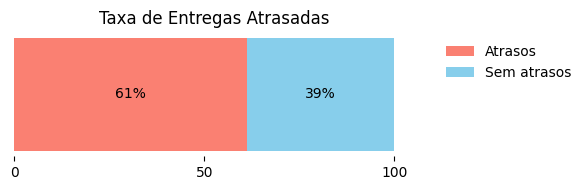

In [17]:
# Agrupando e renomeando os índices
distribuicao_interrupcao = df.groupby('Disruption_Occurred').size()
distribuicao_interrupcao.index = distribuicao_interrupcao.index.map({0: 'No', 1: 'Yes'})

total = distribuicao_interrupcao.sum()
percentages = (distribuicao_interrupcao / total) * 100

fig, ax = plt.subplots(figsize=(6, 2))

# Reordenando 'Yes' (61%) primeiro e 'No' (39%) como 'left'
ax.barh([''], percentages['Yes'], color='salmon', label='Atrasos', height=0.3) # Altura reduzida para 0.3 para barras mais finas
ax.barh([''], percentages['No'], left=percentages['Yes'], color='skyblue', label='Sem atrasos', height=0.3)

# Ajustando a posição dos textos para refletir a nova ordem
ax.text(percentages['Yes'] / 2, 0, f"{percentages['Yes']:.0f}%", ha='center', va='center', color='black', fontsize=10)
ax.text(percentages['Yes'] + percentages['No'] / 2, 0, f"{percentages['No']:.0f}%", ha='center', va='center', color='black', fontsize=10)

plt.title('Taxa de Entregas Atrasadas', fontsize=12)
plt.ylabel('')
plt.yticks([])
plt.xlabel('')
plt.xticks([0, 50, 100])

# Removendo bordas desnecessárias
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

**Insights relevantes:**

Os dados revelam um cenário de alta instabilidade operacional. O índice de interrupções críticas atinge **61%** do volume total de cargas monitoradas, enquanto apenas **39%** das entregas seguem o fluxo planejado (*Perfect Order*) sem intercorrências.

Uma **taxa de atraso/interrupção de 61%** é considerada crítica para operações. Este dado justifica a necessidade de um mergulho profundo nas variáveis de **Clima, Geopolítica e Modal**, a fim de identificar se estas falhas são sistêmicas ou concentradas em gargalos específicos.

###**2.2. Qual modal impacta mais a media do tempo de entrega?**

In [18]:
# fixando cores para cada modal para garintir padrão e clareza na visualizacao dos dados/graficos
cores_modal = {
    'Sea': '#103B53',   # azul
    'Rail': '#F1861A',  # laranja
    'Road': '#D53032',  # verde
    'Air': '#FCD55C'    # amarelo
}

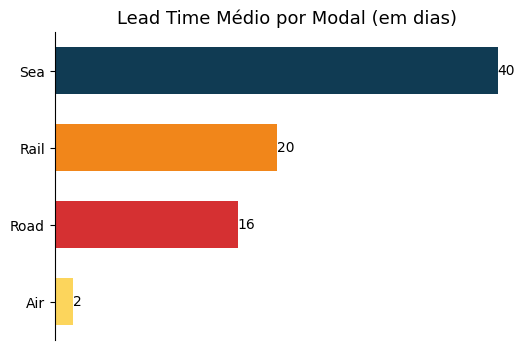

In [19]:
modal_mean = df.groupby('Transport_Mode')['Lead_Time_Days'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(6, 4)) # Ajustar o tamanho para um gráfico horizontal

sns.barplot(data=modal_mean, x='Lead_Time_Days', y='Transport_Mode', hue='Transport_Mode', palette=cores_modal, legend=False, saturation=1, width=0.6)

plt.title('Lead Time Médio por Modal (em dias)', fontsize=13)
plt.xlabel('')
plt.ylabel('') # Remover o rótulo do eixo Y, pois o modal será o rótulo da barra

# Adicionar rótulos de dados (Lead Time médio em dias) em cada barra
for index, row in modal_mean.iterrows():
    plt.text(row['Lead_Time_Days'], index, f"{row['Lead_Time_Days']:.0f}", color='black', ha="left", va="center") # Ajustar a posição para barras horizontais

plt.xticks([]) # Remover os ticks do eixo X

ax = plt.gca()

# Removendo bordas desnecessárias (spines)
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.show()

**Insights relevantes:**

* **Modal Sea (Marítimo)**: Por percorrer as maiores distâncias e lidar com grandes volumes, apresenta o maior Lead Time médio (**40 dias**). Na prática, uma carga marítima leva, em média, **1 mês e 10 dias** para chegar ao destino final, o que exige um planejamento de estoque muito mais antecipado.

* **Modais Terrestres (Rail e Road)**: Ambos operam com um tempo de entrega inferior a um mês (**20 e 16 dias, respectivamente**). Comparados ao modal marítimo, possuem um Lead Time **50% e 60%,  respectivamente,** inferior, oferecendo uma agilidade intermediária para a malha logística.

* **Modal Air (Aéreo)**: É o modal de resposta imediata, levando apenas **2 dias** para a entrega final. Sendo o mais rápido entre os quatro analisados, ele se consolida como a via preferencial para itens de altíssima urgência, embora com as restrições de carga já mencionadas.

###**2.3. Qual o atraso real em dias para cada modal dada a condição climática?**




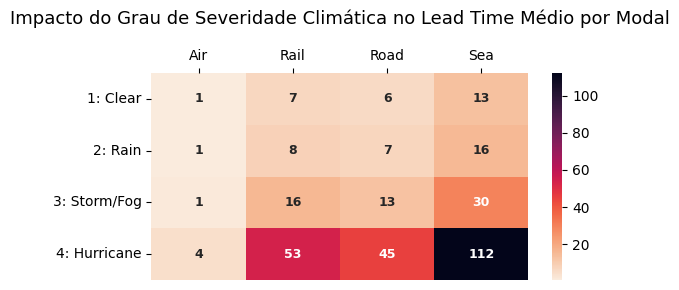

In [20]:
# Mapeamento para substituir números por nomes de forma clara
clima_nomes = {1: '1: Clear', 2: '2: Rain', 3: '3: Storm/Fog', 4: '4: Hurricane'}

# 1. Calculando a média de Lead Time e remodelando para o formato de tabela
# index = linhas (vertical), columns = colunas (horizontal)
df_clima_pivot = df.pivot_table(index='Weather_Severity_Rank',
                                columns='Transport_Mode',
                                values='Lead_Time_Days',
                                aggfunc='mean')

# Substituindo os códigos numéricos pelos nomes claros no índice (vertical)
df_clima_pivot.index = df_clima_pivot.index.map(clima_nomes)

# Garantindo que a ordem das linhas seja 1 (topo) a 4 (base) para lógica de tabela
df_clima_pivot = df_clima_pivot.reindex(['1: Clear', '2: Rain', '3: Storm/Fog', '4: Hurricane'])

plt.figure(figsize=(6, 3))


ax = sns.heatmap(df_clima_pivot,
                 annot=True, # annot=True: exibe os valores nas células
                 fmt=".0f",
                 cmap='rocket_r',
                 annot_kws={"size": 9, "weight": "bold"})


plt.title('Impacto do Grau de Severidade Climática no Lead Time Médio por Modal\n', fontsize=13, pad=20)

# Colocando os rótulos do eixo X no topo (estilo cabeçalho de tabela)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Insights relevantes:**

* **Modal Air (Aéreo)**: Dentre os quatro modais, o aéreo é o mais resiliente sob a perspectiva climática. Observa-se que apenas em casos de severidade grau 4 (Hurricane) o modal sofre uma alteração significativa, aumentando o tempo médio de entrega (Lead Time) em **300%** (de **1 para 4 dias**).

* **Modal Rail (Ferroviário):** O impacto torna-se crítico a partir do grau 3 de severidade. Em cenários de nevoeiro (**Fog**) e furacão (**Hurricane**), o Lead Time aumenta drasticamente em **128%**(de 7 para 16) e **657%** (de 7 para 53), respectivamente, em relação às condições de céu limpo (Clear).

* **Modal Road (Rodoviário):** Este modal apresenta comportamento similar ao ferroviário. A partir do grau 3, o Lead Time médio aumenta **116%** (de 6 para 13) ao enfrentar situações de nevoeiro e **650%** (de 6 para 45) em condições extremas de furacão.

* **Modal Sea (Marítimo):** É o modal mais vulnerável a variações climáticas e janelas operacionais. Em situações de nevoeiro, o tempo médio de entrega cresce **131%** (de 13 para 30), enquanto em cenários de furacão, o impacto é severo, atingindo um aumento expressivo de **760%** (de 13 para 112) em relação a dias com condições climáticas favoráveis.
---

**Análise de Contingência Terrestre (Rail vs. Road):**

* A comparação entre os modais terrestres revela que o transporte rodoviário (**Road**) apresenta maior resiliência em cenários de crise, mantendo uma vantagem de **8 dias** (45 vs. 53 dias), isto é em média **18% mais ágil** em condições extremas de furacão (Hurricane) em relação ao ferroviário (**Rail**).

* Essa diferença ocorre porque a malha ferroviária possui uma rigidez estrutural que impede desvios, enquanto o modal rodoviário permite rotas alternativas em caso de bloqueios físicos.

Logo, o modal **Road** torna-se a principal alternativa de escape e redundância para cargas pesadas embora o **Rail** (ferroviário) seja eficiente em condições normais, a flexibilidade do caminhão deve ser considerada em situações de paralisias operacionais a fim de garantir a continuidade do suprimento sob severidade climática.



###**2.4. Quantas entregas de cada modal foram On-time/Delayed/Critical?**

* ***Análise de Nível de Serviço (SLA)***

In [21]:
# definindo as cores para cada nível de serviço (SLA)

cores_sla = {
  'On-time': '#fbb593', # Pessego (Bom)
  'Delayed': '#D91E49', # Rosa (Atenção)
  'Critical': '#140B2E' # Roxo (Crítico)
}

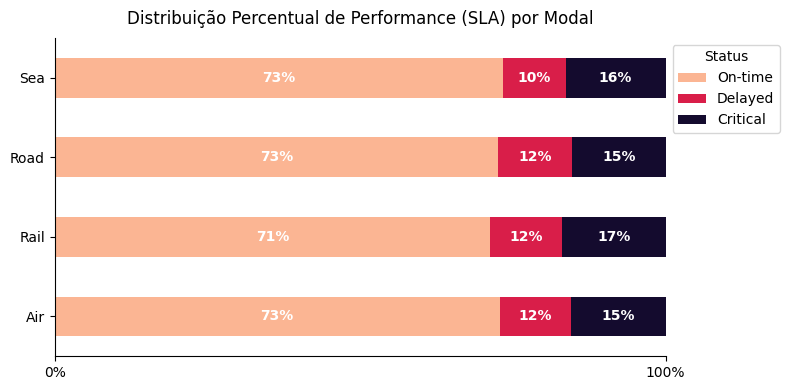

In [22]:
# Voltando ao df_processed (normalizacao e discretizacao)
# 'normalize=index' garante que a soma de cada linha (modal) seja 100%
dist_percentual = pd.crosstab(df_processed['Transport_Mode'],
                              df_processed['Lead_Time_Category'],
                              normalize='index') * 100

# Reordenar as colunas para a lógica visual: Do melhor para o pior
ordem_status = ['On-time', 'Delayed', 'Critical']
dist_percentual = dist_percentual[ordem_status]


# gráfico de barras horizontais empilhadas --  Pessego (Bom), Rosa (Atenção), Roxo (Crítico)
fig, ax = plt.subplots(figsize=(8, 4))

dist_percentual.plot(kind='barh', stacked=True, ax=ax,
                     color=cores_sla, edgecolor='none')

# 4. Adicionar os rótulos de porcentagem dentro das barras
for p in ax.patches:
    width = p.get_width()
    if width > 3: # Só escreve o número se a fatia for visível (>3%)
        ax.annotate(f'{width:.0f}%',
                    (p.get_x() + width / 2, p.get_y() + p.get_height() / 2),
                    ha='center', va='center', color='white',
                    fontweight='bold', fontsize=10)

# Ajustes estéticos de dataviz
plt.title('Distribuição Percentual de Performance (SLA) por Modal', fontsize=12, pad=10)
plt.xlabel('')
plt.ylabel('')
plt.legend(title='Status', bbox_to_anchor=(1.0, 1), loc='upper left')

plt.xlim(0, 100)
plt.xticks([0, 100]) # Set the tick locations

ax.set_xticklabels(['0%', '100%'])


# Removendo bordas desnecessárias
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Insights interessantes:**

Ao analisar a performance de SLA agrupada puramente por modal de transporte, observa-se uma **distribuição de riscos surpreendentemente uniforme**. Todos os modais apresentam uma taxa de pedidos em estado Crítico próxima a **20%**.

> *Essa homogeneidade sugere que a vulnerabilidade da cadeia de suprimentos não está concentrada em um único meio de transporte, mas sim em fatores externos que impactam a malha de forma transversal.*

Este *gráfico serve como um ponto de partida* que motiva a investigação subsequente. Ele demonstra que, independentemente de a carga viajar por mar, terra ou ar, a exposição ao risco severo é constante, o que nos obriga a olhar para os features externas (como o Clima) para entender onde a resiliência é realmente testada.

###**2.5. Como se distribui a confiabilidade operacional e como o clima altera essa percepção?**

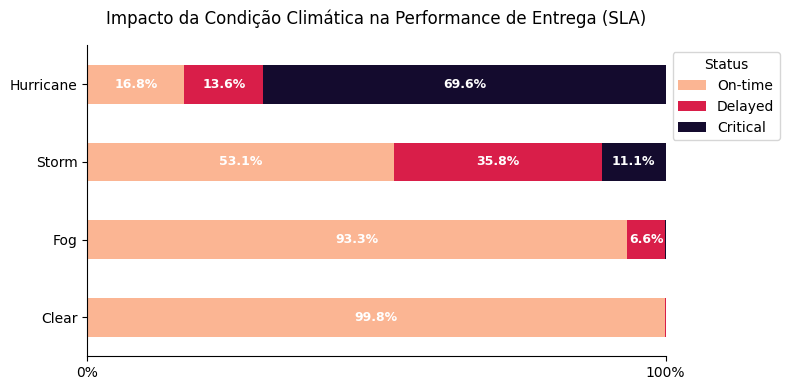

In [23]:
# Criar a tabela de frequências cruzadas (Crosstab)
dist_weather = pd.crosstab(df_processed['Weather_Condition'],
                           df_processed['Lead_Time_Category'],
                           normalize='index') * 100


# Status do positivo para o crítico
ordem_status = ['On-time', 'Delayed', 'Critical']
# Clima: Da menor severidade para a maior (ordem do Encoding)
ordem_clima = ['Clear', 'Fog', 'Storm', 'Hurricane']

# Aplicando a reordenação (reindex)
dist_weather = dist_weather.reindex(index=ordem_clima, columns=ordem_status)

# grafico de barras empilhadas
fig, ax = plt.subplots(figsize=(8, 4))
dist_weather.plot(kind='barh', stacked=True, ax=ax,
                  color=cores_sla, edgecolor='none')

# rotulos de porcentagem
for p in ax.patches:
    width = p.get_width()
    if width > 3: # Apenas para fatias visíveis
        ax.annotate(f'{width:.1f}%',
                    (p.get_x() + width / 2, p.get_y() + p.get_height() / 2),
                    ha='center', va='center', color='white',
                    fontweight='bold', fontsize=9)

# Ajustes de dataviz
plt.title('Impacto da Condição Climática na Performance de Entrega (SLA)', fontsize=12, pad=15)
plt.xlabel('')
plt.ylabel('')
plt.legend(title='Status', bbox_to_anchor=(1.0, 1), loc='upper left')

plt.xlim(0, 100)
plt.xticks([0, 100]) # Set the tick locations

ax.set_xticklabels(['0%', '100%'])

# Removendo bordas desnecessárias
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)


plt.tight_layout()
plt.show()

**Insights interessantes:**

Quando incluimos a feature `weather_condition` na análise é possível entender melhor a performance de SLA do Lead Time:

* **Clear & Fog**: Nestas condições, a operação é altamente previsível, com o tempo limpo (Clear) **99.8%**, isto é, praticamente todas as entregas chegam no tempo pre-estabelecido. Em dias de nevoeiro (Fog) **93.3%** das entregas também fiquem dentro do prazo esperado para cada modal.

* **Storm**: Em casos de tempestades, a probabilidade da mercadoria chegar com um atraso médio aumenta para **35,8%** em comparação com entregas com tempo limpo onde as chances de qualquer atraso é quase nulas. Houve, também, um aumento expressivo de **11.1%** em relação a entrgas criticas. Nota-se, portanto, que ambos resultados tiveram aumentos significativos e requerem um plano de contingência para que este aumento não se torne um gargalo futuramente.

* **Hurricane**: Sob esta condição extrema, **69.6%** das entregas entram em estado *Crítico*. Isso indica que não se trata de um simples atraso, mas de uma interrupção sistêmica que invalida o planejamento logístico padrão.

Desta forma, cresce a necessidade de planos de contingência diferenciados por severidade climática, uma vez que o risco de ruptura crítica aumenta substancialmente (de **0% para quase 70%**) entre um céu limpo (Clear) e um evento de furacão (Hurricane).

###**2.6. Qual é o impacto das interrupções (`Disruption_Occurred`) no tempo médio de entrega (*Lead Time médio*) de cada modal?**

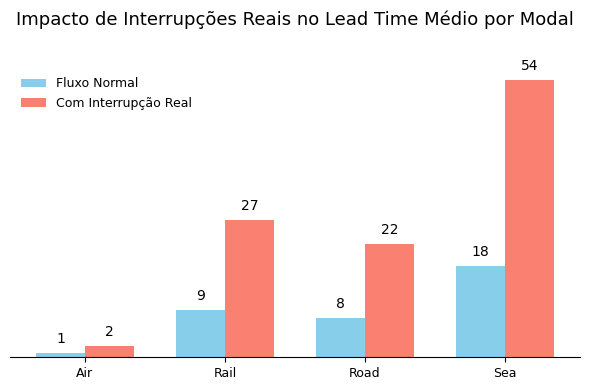

In [24]:
# o impacto REAL das interrupções
disruption_impact = df.groupby(['Transport_Mode', 'Disruption_Occurred'])['Lead_Time_Days'].mean().unstack()


fig, ax = plt.subplots(figsize=(6, 4))
width = 0.35
x = np.arange(len(disruption_impact.index))

# Criando as barras
bar1 = ax.bar(x - width/2, disruption_impact[0], width, label='Fluxo Normal', color='skyblue')
bar2 = ax.bar(x + width/2, disruption_impact[1], width, label='Com Interrupção Real', color='salmon')

# adicionando os rotulos no topo das barras
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.0f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 pontos de deslocamento vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

add_labels(bar1)
add_labels(bar2)

ax.set_title('Impacto de Interrupções Reais no Lead Time Médio por Modal',
             fontsize=13, loc='center', pad=30)

ax.set_yticks([])
ax.set_ylabel('')

# Ajustando o Eixo X
ax.set_xticks(x)
ax.set_xticklabels(disruption_impact.index, fontsize=9)

# Removendo bordas
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

**Insights relevantes:**

Enquanto o risco geopolítico é uma probabilidade, o atributo `Disruption_Occurred` representa o evento já concretizado (bloqueios, greves ou falhas mecânicas). Esta análise revela o quão sensível cada modal se torna quando o fluxo planejado é interrompido:

> **Modal Air (Aéreo):**

* Apesar de **dobrar o tempo de entrega**, o impacto prático é de apenas **1 dia adicional**.

* Mesmo em cenários de colapso, o modal entrega o componente em até 48h. Isso o consolida como a única opção viável para peças de reposição crítica (spares) que mantêm a continuidade da operação.

> **Modais Terrestres (Rail & Road):**

* **Rail (Ferroviário)**: Apresenta a maior sensibilidade relativa junto com o marítimo (**200%**). Isso reflete a **rigidez da malha**: em caso de interrupção em um trecho, a ausência de rotas de fuga acaba por **triplicar** o tempo de espera (**9 para 27 dias**).

* **Road (Rodoviário)**: Embora sofra um aumento expressivo de **175%,** demonstra maior flexibilidade que o ferroviário (**22 vs 27 dias** no cenário de crise). Essa vantagem deve-se à capacidade de redirecionamento dinâmico que a malha rodoviária permite frente a bloqueios físicos.

> **Modal Sea (Marítimo):**

* Sofre um aumento drástico de **200%**, saltando de **18 para 54 dias**, sendo assim o modal mais sensível para a continuidade operacional.

* Um **atraso de 36 dias** (mais de um mês) em suprimentos de grande portepode desestruturar cronogramas inteiros e gerar multas contratuais pesadas. No modal marítimo, a interrupção deixa de ser um mero atraso e torna-se um gargalo crítico para a operação.


###**2.7. Qual é a probabilidade da entrega ultrapassar o Lead Time médio do modal dado o Risco Geopolítico?**

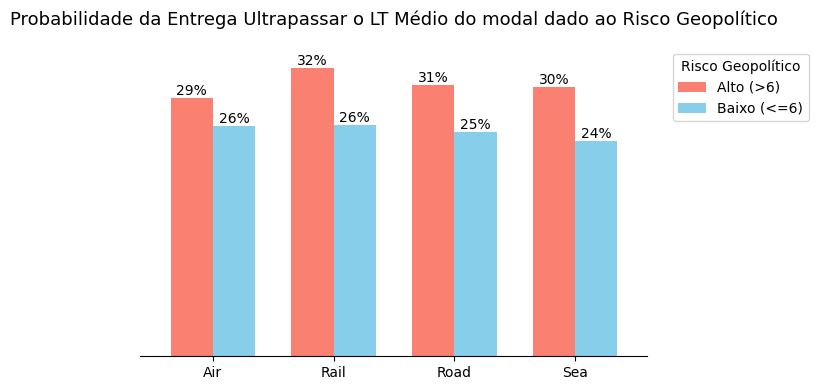

In [25]:
# calculando a média de Lead Time para CADA modal
medias_por_modal = df.groupby('Transport_Mode')['Lead_Time_Days'].mean()

# criando uma função para marcar o atraso relativo
def check_atraso_relativo(row):
    media_do_modal = medias_por_modal[row['Transport_Mode']]
    return 1 if row['Lead_Time_Days'] > media_do_modal else 0

df['Atraso_Relativo'] = df.apply(check_atraso_relativo, axis=1)

# preparando o gráfico comparativo
df['Risk_Level'] = df['Geopolitical_Risk_Score'].apply(lambda x: 'Baixo (<=6)' if x <= 6 else 'Alto (>6)')
grafico_dados = df.groupby(['Transport_Mode', 'Risk_Level'])['Atraso_Relativo'].mean().unstack() * 100


ax = grafico_dados.plot(kind='bar', figsize=(7, 4), color=['salmon', 'skyblue'], width=0.7)

plt.title('Probabilidade da Entrega Ultrapassar o LT Médio do modal dado ao Risco Geopolítico\n', fontsize=13)
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Risco Geopolítico', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.yticks([])
plt.ylabel('')

ax = plt.gca()

# Removendo bordas
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# Adicionar rótulos em cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='edge')

plt.tight_layout()
plt.show()

**Insights relevantes:**

* O modal **Air** é, evidentemente, o mais confiável em tempos de crise. O aumento na probabilidade de atraso é a menor entre os quatro (**11,5%**, saltando de 26% para 29%). Embora seja o modal mais seguro para manter a operação, sua capacidade é limitada pela impossibilidade técnica de transportar equipamentos de grande porte ou peso excessivo.

* Os modais **Road (24%) e Rail (23%)** apresentam as maiores taxas de vulnerabilidade operacional em tempos de clima geopolítico fica mais instável. Logo, cargas transportadas nestes modais tem rota com risco geopolitico > 6 devem possuir um estoque de segurança *(safety stock)* para suprir qualquer paralisão e evitar perdas na produção.

* O modal martimo, **Sea (25%)**, é o mais vulnerável entre os quatro, principalmente, em tempos de crise geopolitica. Como vemos atualmente no Oriente Médio onde o acesso restrito a pontos estratégicos, como o Estreito de Ormuz (Irã/Pérsia), transforma o risco geopolítico em paralisia operacional, retendo cargas por tempo indeterminado e elevando drasticamente o custo e a incerteza deste modal.


###**2.8. Quão exposto o Lead Time médio de cada modal fica com o impacto do risco geopolítico?**

* **Indice de Exposição por modal:**

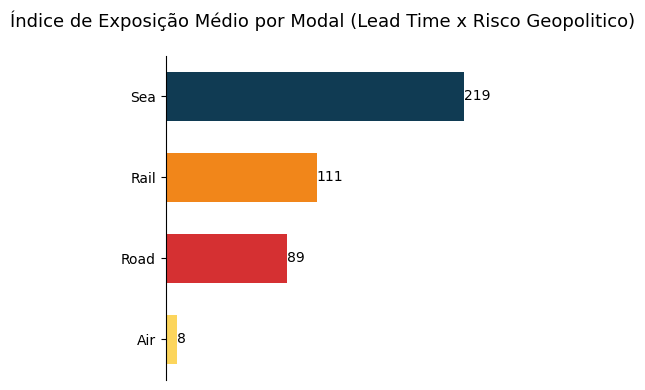

In [26]:
# media do Índice de Exposição por Modal
df['Exposure_Index'] = df['Lead_Time_Days'] * df['Geopolitical_Risk_Score'] # a multiplicacao é utilizada porque o risco tem um efeito cumulativo sobre o tempo.

modal_exposure = df.groupby('Transport_Mode')['Exposure_Index'].mean().sort_values(ascending=False).reset_index()

# grafico
plt.figure(figsize=(4, 4))
sns.barplot(data=modal_exposure, x='Exposure_Index', y='Transport_Mode', hue='Transport_Mode', palette=cores_modal, legend=False, saturation=1, width=0.6)

plt.title('Índice de Exposição Médio por Modal (Lead Time x Risco Geopolitico)\n', fontsize=13)
plt.xlabel('')
plt.ylabel('') # Remover o rótulo do eixo Y, pois o modal será o rótulo da barra

# Adicionando rótulos
for index, row in modal_exposure.iterrows():
    plt.text(row['Exposure_Index'], index, f'{row['Exposure_Index']:.0f}', color='black', ha='left', va='center', fontsize=10)

plt.xticks([]) # Remover os ticks do eixo X

ax = plt.gca()

# Removendo bordas desnecessárias
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Insights relevantes:**

* O **modal aéreo (Air)**, com um índice residual de **8**, confirma sua posição não apenas como um modal rápido, mas como uma ferramenta de seguro operacional.

* O **modal marítimo (Sea)** apresenta um Índice de Exposição de **219**, o que é quase **26 vezes** maior que o **modal aéreo (Air)**. Isso demonstra que o frete marítimo carrega um custo oculto de exposição a riscos de atraso e incertezas geopolíticas extremamente elevado.

* Os modais **Rail e Road** operam em uma faixa de exposição intermediária (**89 e 110, respectivamente**). A diferença de **24%** sugere que, embora o ferroviário suporte mais carga, ele expõe a companhia a um risco de atraso ligeiramente superior ao rodoviário.

O índice de Exposição poderá ser utilizado para o cálculo de ***Safety Stock*** (estoque de segurança). Estipular um valor limite de exposição para cada modal, o que exigiria níveis de estoque mais agressivos para evitar a ruptura da linha de produção em caso de eventos geopolíticos adversos.

* **Impacto no SLA**

*Para entender como esse risco se traduz na percepção do cliente final, aplicou-se a mesma **discretização** de SLA utilizada na análise climática.*

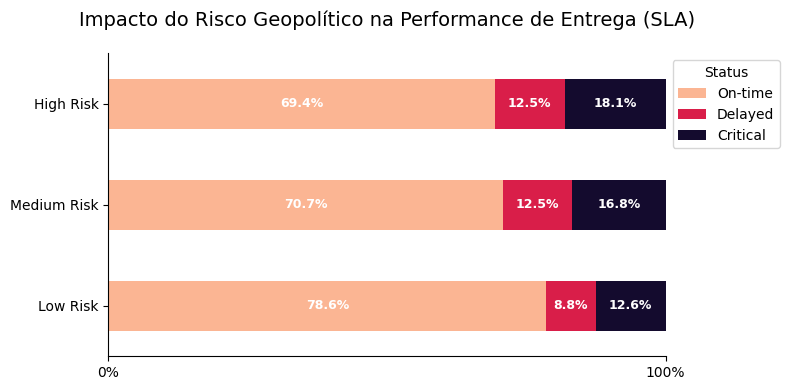

In [27]:
# Criando categorias para o Risco Geopolítico (Discretização)

# Definimos as faixas: 0-3 (Baixo), 3-7 (Médio), 7-10 (Alto)
df_processed['Geopolitical_Risk_Level'] = pd.cut(df_processed['Geopolitical_Risk_Score'],
                                                 bins=[-0.1, 0.3, 0.7, 1.01],
                                                 labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Criando a tabela de frequências cruzadas (Crosstab)
dist_geo = pd.crosstab(df_processed['Geopolitical_Risk_Level'],
                       df_processed['Lead_Time_Category'],
                       normalize='index') * 100

# Reordenação (Garantir que os nomes batam com o que criamos antes)
ordem_status = ['On-time', 'Delayed', 'Critical']
dist_geo = dist_geo.reindex(columns=ordem_status)

# Grafico
fig, ax = plt.subplots(figsize=(8, 4))
dist_geo.plot(kind='barh', stacked=True, ax=ax,
              color=cores_sla, edgecolor='none')

# Adicionando os rótulos de porcentagem
for p in ax.patches:
    width = p.get_width()
    if width > 3:
        ax.annotate(f'{width:.1f}%',
                    (p.get_x() + width / 2, p.get_y() + p.get_height() / 2),
                    ha='center', va='center', color='white',
                    fontweight='bold', fontsize=9)

# Dataviz
plt.title('Impacto do Risco Geopolítico na Performance de Entrega (SLA)', fontsize=14, pad=20)
plt.xlabel('')
plt.ylabel('')

plt.legend(title='Status', bbox_to_anchor=(1.0, 1), loc='upper left')
plt.xlim(0, 100)
plt.xticks([0, 100]) # Set the tick locations
ax.set_xticklabels(['0%', '100%'])

# Removendo bordas desnecessárias
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)


plt.tight_layout()
plt.show()

**Insights interessantes:**

Nota-se que o agravamento do risco geopolítico (*transição de Low para High Risk*) eleva em **45%** a base da taxa sistêmica de entregas **Critical**, chegando a um patamar de **18.1%** de ruptura sob alto risco.

Portanto, diferente de um evento climático severo, *que causa uma ruptura abrupta e generalizada*, o risco geopolítico atua como uma fricção crônica. Isto é, não destrói o SLA da noite para o dia na mesma proporção de um furacão, mas impõe um atraso severo e contínuo, focado quase exclusivamente nas rotas marítimas.

# **3. Conclusão**

A partir da taxa de interrupção de **61%** e da análise do comportamento das variáveis climáticas, geopolíticas e operacionais no tempo de entrega dos suprimentos, as principais conclusões foram:

> **O modal maritimo (Sea)**: Embora inevitável para o transporte de grandes volumes, é o ponto de maior gargalo da cadeia.

* Possui o maior tempo médio (LT = 40 dias) e um Índice de Exposição **26 vezes** maior que o aéreo.

* Em cenários extremos (furacões), o tempo de entrega sofre picos de até **760%**.

* Interrupções reais triplicam sua latência, adicionando **36 dias extras** ao cronograma, um atraso residual suficiente para paralisar operações e gerar multas severas.


> **Os modais terrestres (Road & Rail**: Na comparação terrestre, o caminhão (Road) consolida-se como a principal válvula de escape frente ao trem (Rail).

* A rigidez estrutural do modal ferroviário (Rail) impede desvios em crises, fazendo seu Lead Time também **triplicar** sob interrupção.

* O modal rodoviário (Road) permite redirecionamento dinâmico. Isso faz com que absorva melhor o impacto, garantindo entregas até **18% mais ágeis** (uma vantagem de 8 dias) em cenários de intercorrência climática.


> **O modal Aéreo (Air)**: Provou ser o único amortecedor confiável de todo o sistema logístico.

* É incrivelmente resiliente: além de ser o mais rápido (**2 dias**), a pior interrupção possível **adiciona apenas 1 dia** ao seu prazo final.

* Justifica seu custo elevado como via exclusiva para peças críticas, pois raramente é paralisado por bloqueios climáticos ou geográficos.

* Apesar de sua resiliência, não atua como substituto em massa para os demais modais devido a severas restrições de peso, volume e custo.

* Assim como os caminhões, usufrui da mudança de rota sob bloqueios. Um exemplo real é a atual adaptação de rotas no Oriente Médio frente ao conflito entre Irã(Pérsia) e Israel/EUA, comprovando sua capacidade de contornar crises geopolíticas de forma rápida.

#**4. Possíveis Planos de Ação**

**1. Implementar Safety Stock Dinâmico**
* Abandonar o uso exclusivo de médias históricas de entrega. O estoque de segurança deve ser dimensionado pelo Índice de Exposição (Lead Time x Risco Geopolítico).

* Como as cargas do modal **Marítimo (Sea)** possuem volumes massivos e não podem ser migradas para o modal aéreo em caso de crise, a aplicação de margens de estoque agressivas torna-se a única defesa viável para evitar o desabastecimento.

**2. Estabelecer o modal rodoviário como a rota de escape oficial e imediata em cenários de crise aguda no continente.**

* Por suportar perfis de carga similares aos trens, sua flexibilidade de redirecionamento dinâmico deve ser ativada antes que a carga fique retida em modais rígidos como o Ferroviário (Rail).

**3. Usufruir do Modal Aéreo (Air) para "Micro-Contingências"**.

* Dado o seu **baixo Índice de Exposição (8)** e as severas restrições de capacidade volumétrica e custo, *o frete aéreo jamais deve ser acionado na tentativa de absorver gargalos da operação principal (marítima).* Seu uso deve ser estritamente protocolado para "salvar" a linha de produção, transportando exclusivamente peças de reposição urgentes, críticas e de alto valor agregado.

**4. Desenvolver um alerta preventivo frente a previsões de eventos climáticos extremos (furacões)**.

* Como é fisicamente inviável transferir os grandes volumes do mar para o ar de última hora, a estratégia deve focar em *antecipar os prazos de despacho* ou *redirecionar preventivamente as cargas para portos fora da rota da tempestade*, mitigando a exposição à ruptura de quase **70% do SLA**.
